# Entrenamiento YOLOv8 para deteccion de placas

Este cuaderno prepara el dataset, entrena varios modelos YOLOv8, muestra las graficas de Colab, evalua los resultados y conserva los tres mejores pesos.

Puedes montar Google Drive y guardar alli los pesos generados.

In [1]:
# Instala las dependencias necesarias para YOLO y CV
# Si PyTorch no tiene CUDA en este kernel, se usará CPU automaticamente.
#%pip install -q ultralytics opencv-python-headless pillow pandas matplotlib seaborn

import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import shutil
from collections import Counter
import json
import random
import cv2
from ultralytics import YOLO
import torch
import time


In [2]:
print('Python:', sys.version)
print('Ejecutable:', sys.executable)
print('CUDA en torch:', torch.version.cuda)
print('Torch disponible:', torch.__version__)
print('CUDA disponible en PyTorch:', torch.cuda.is_available())
print('Numero de GPUs CUDA visibles:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('GPU actual:', torch.cuda.get_device_name(0))
else:
    print('ADVERTENCIA: PyTorch no ve CUDA en este kernel. El entrenamiento usara CPU o fallara al pedir device=0.')

!{sys.executable} -V
!nvidia-smi

Python: 3.13.0 (main, Sep 11 2026, 18:34:43) [GCC 15.2.0]
Ejecutable: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/.venv/bin/python
CUDA en torch: 12.8
Torch disponible: 2.11.0+cu128
CUDA disponible en PyTorch: True
Numero de GPUs CUDA visibles: 1
GPU actual: NVIDIA GeForce RTX 5050 Laptop GPU
Python 3.13.0
Sun Sep 13 00:25:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.61                 Driver Version: 595.95         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  

## 1. Configuracion de rutas

El dataset original debe subirse una sola vez a Google Drive. Colab lo copia a `/content` para entrenar desde el almacenamiento local, que es mas rapido. La copia local se pierde al reiniciar la sesion, pero se vuelve a crear automaticamente desde Drive.

- `DRIVE_PROJECT_ROOT`: carpeta persistente `MyDrive/Placas`.
- `DRIVE_DATA_ROOT`: dataset original en Drive (`models/Data/images` y `models/Data/labels`).
- `PROJECT_ROOT`: copia del proyecto disponible en `/content/Placas`; debe contener `models/ia.py`.
- `DATA_ROOT`: copia local temporal del dataset usada para preparar y entrenar.
- `DATASET_ROOT`: dataset YOLO convertido, con `train` y `val`, en almacenamiento local.
- `FINAL_TEST_ROOT`: conjunto final aislado en Drive.
- `RUNS_ROOT`: checkpoints `last.pt` y `best.pt` en Drive.
- `OUTPUT_ROOT`: top 3, configuraciones y resultados en Drive.

Debes subir a Drive el dataset original y el proyecto que contiene `models/ia.py`. Deja `REBUILD_DATASET = False` para reutilizar la particion ya creada; usa `True` si cambias las imagenes o etiquetas.

In [3]:
PROJECT_CANDIDATES = [
    Path('/home/lukga/Programacion/CienciaDeDatos/clase/Placas'),
    Path('/content/Placas'),
    Path.cwd() / 'Placas',
]
PROJECT_ROOT = next(
    (candidate for candidate in PROJECT_CANDIDATES if (candidate / 'models').is_dir()),
    PROJECT_CANDIDATES[0],
)
DRIVE_PROJECT_ROOT = PROJECT_ROOT
SOURCE_DATA_CANDIDATES = [
    PROJECT_ROOT / 'models' / 'Data',
    PROJECT_ROOT / 'models' / 'training_data',
]
DRIVE_DATA_ROOT = next(
    (
        candidate for candidate in SOURCE_DATA_CANDIDATES
        if (candidate / 'images').is_dir() and (candidate / 'labels').is_dir()
    ),
    SOURCE_DATA_CANDIDATES[0],
)

DATA_ROOT = PROJECT_ROOT / 'models' / 'Data'
DATASET_ROOT = PROJECT_ROOT / 'models' / 'yolo_dataset_final_holdout'

FINAL_TEST_ROOT = PROJECT_ROOT / 'final_test_holdout'
OUTPUT_ROOT = PROJECT_ROOT / 'top_models'
RUNS_ROOT = PROJECT_ROOT / 'runs_colab'

WEIGHTS = 'yolov8n.pt'

# Usa GPU si el kernel tiene CUDA disponible; si no, usa CPU.
DEVICE = '0' if torch.cuda.is_available() else 'cpu'

SEED = 42
TRIALS = 15
EPOCHS = 500
IMAGE_SIZE = 640
BATCH_SIZE = 32 if torch.cuda.is_available() else 4
WORKERS = 2
PATIENCE = 10
FINAL_TEST_RATIO = 0.20
INNER_VAL_RATIO = 0.20
REBUILD_DATASET = False
CLASS_NAMES = None
TARGET_CLASS_IDS = {0}

if not DRIVE_DATA_ROOT.is_dir():
    raise FileNotFoundError(
        f'No se encontro un dataset fuente en {SOURCE_DATA_CANDIDATES}. '
        'Verifica que exista images/ y labels/.'
    )

if REBUILD_DATASET or not (DATA_ROOT / 'images').is_dir() or not (DATA_ROOT / 'labels').is_dir():
    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)
    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(DRIVE_DATA_ROOT, DATA_ROOT)

# En local, training_data puede ser solo el subconjunto de entrenamiento.
# Se agrega la reserva final para reconstruir la fuente completa.
if (FINAL_TEST_ROOT / 'images').is_dir():
    for split in ('images', 'labels'):
        (DATA_ROOT / split).mkdir(parents=True, exist_ok=True)
        for source_path in (FINAL_TEST_ROOT / split).iterdir():
            destination = DATA_ROOT / split / source_path.name
            if not destination.exists():
                shutil.copy2(source_path, destination)

PROJECT_ROOT.joinpath('models').mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_TEST_ROOT.mkdir(parents=True, exist_ok=True)
print(f'Dataset original en Drive: {DRIVE_DATA_ROOT}')
print(f'Copia local usada para entrenar: {DATA_ROOT}')
print(f'Dataset de entrenamiento/validacion: {DATASET_ROOT}')
print(f'Datos reservados para evaluacion final: {FINAL_TEST_ROOT}')
print(f'Checkpoints persistentes: {RUNS_ROOT}')
print(f'Mejores modelos: {OUTPUT_ROOT}')
print(f'Clases conservadas: {TARGET_CLASS_IDS}')
print(f'Dispositivo activo: {DEVICE}')

Dataset original en Drive: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/models/Data
Copia local usada para entrenar: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/models/Data
Dataset de entrenamiento/validacion: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/models/yolo_dataset_final_holdout
Datos reservados para evaluacion final: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/final_test_holdout
Checkpoints persistentes: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/runs_colab
Mejores modelos: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/top_models
Clases conservadas: {0}
Dispositivo activo: 0


## 2. Division y revision del dataset

Se reserva aleatoriamente el 20% de las imagenes como evaluacion final. Esas imagenes no se copian al dataset de YOLO y no se usan para entrenar, validar, elegir hiperparametros ni aplicar early stopping.

El 80% restante se divide en 80% entrenamiento y 20% validacion interna. Por tanto, sobre el total queda:

- `64%`: entrenamiento.
- `16%`: validacion interna para early stopping y seleccion durante las pruebas.
- `20%`: evaluacion final, tocado solo despues de seleccionar el modelo.

La semilla hace que la reserva sea aleatoria pero reproducible. Si `REBUILD_DATASET = False`, una reserva ya creada se conserva para no cambiar la comparacion entre modelos. YOLO baraja los ejemplos de entrenamiento en cada epoca; la validacion interna permanece fija, que es lo correcto para que early stopping sea comparable. Cambiar tambien la validacion en cada epoca produciria una metrica ruidosa y podria introducir fuga de informacion.

In [4]:
BLUR_THRESHOLD = 3.0
QUARANTINE_ROOT = PROJECT_ROOT / "models" / "blur_review"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def blur_score(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    return float(cv2.Laplacian(image, cv2.CV_64F).var())

blurred_files = []

for image_path in (DATA_ROOT / "images").iterdir():
    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    score = blur_score(image_path)

    if score is not None and score < BLUR_THRESHOLD:
        blurred_files.append((image_path, score))

print(f"Candidatas borrosas: {len(blurred_files)}")

for image_path, score in blurred_files:
    destination_image = QUARANTINE_ROOT / "images"
    destination_label = QUARANTINE_ROOT / "labels"

    destination_image.mkdir(parents=True, exist_ok=True)
    destination_label.mkdir(parents=True, exist_ok=True)

    shutil.move(str(image_path), destination_image / image_path.name)

    label_path = DATA_ROOT / "labels" / f"{image_path.stem}.txt"
    if label_path.exists():
        shutil.move(str(label_path), destination_label / label_path.name)

print(f"Archivos movidos a: {QUARANTINE_ROOT}")

Candidatas borrosas: 0
Archivos movidos a: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/models/blur_review


In [5]:
REBUILD_DATASET = True

In [15]:
def read_yolo_label(label_path: Path) -> tuple[list[str], int | None]:
	"""Validate labels and normalize only the selected classes to YOLO boxes."""
	normalized: list[str] = []
	maximum_class: int | None = None

	for line_number, line in enumerate(label_path.read_text().splitlines(), 1):
		values = line.split()
		if not values:
			continue
		if len(values) < 5 or (len(values) > 5 and len(values) % 2 == 0):
			raise ValueError(
				f"{label_path.name}:{line_number}: expected 5 box values "
				"or class plus an even number of polygon coordinates"
			)

		try:
			class_id = int(values[0])
			coordinates = [float(value) for value in values[1:]]
		except ValueError as error:
			raise ValueError(f"{label_path.name}:{line_number}: non-numeric value") from error

		if class_id not in TARGET_CLASS_IDS:
			continue
		if class_id < 0 or any(value < 0 or value > 1 for value in coordinates):
			raise ValueError(f"{label_path.name}:{line_number}: values must be in [0, 1]")

		if len(coordinates) == 4:
			center_x, center_y, width, height = coordinates
		else:
			x_values = coordinates[::2]
			y_values = coordinates[1::2]
			x_min, x_max = min(x_values), max(x_values)
			y_min, y_max = min(y_values), max(y_values)
			center_x = (x_min + x_max) / 2
			center_y = (y_min + y_max) / 2
			width = x_max - x_min
			height = y_max - y_min

		if width <= 0 or height <= 0:
			raise ValueError(f"{label_path.name}:{line_number}: empty bounding box")

		normalized.append(
			f"0 {center_x:.8f} {center_y:.8f} {width:.8f} {height:.8f}"
		)
		maximum_class = 0

	return normalized, maximum_class


def build_dataset(data_root: Path, output_root: Path, val_ratio: float, seed: int, force: bool) -> tuple[Path, list[str]]:
	image_root = data_root / "images"
	label_root = data_root / "labels"
	if not image_root.is_dir() or not label_root.is_dir():
		raise FileNotFoundError("The data root must contain images/ and labels/ folders")
	if not 0 < val_ratio < 1:
		raise ValueError("--val-ratio must be between 0 and 1")

	pairs = []
	class_ids = Counter()
	invalid_files = []
	label_paths = {path.stem: path for path in label_root.glob("*.txt")}

	for image_path in sorted(image_root.iterdir()):
		if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
			continue
		label_path = label_paths.get(image_path.stem)
		if label_path is None:
			invalid_files.append(f"missing label: {image_path.name}")
			continue
		try:
			normalized, maximum_class = read_yolo_label(label_path)
			if maximum_class is not None:
				for row in normalized:
					class_ids[int(row.split()[0])] += 1
			with Image.open(image_path) as image:
				image.verify()
			pairs.append((image_path, normalized))
		except (OSError, ValueError) as error:
			invalid_files.append(f"invalid pair: {image_path.name} ({error})")

	if not pairs:
		raise RuntimeError("No valid image/label pairs were found")
	if force and output_root.exists():
		shutil.rmtree(output_root)
	existing_yaml = output_root / "dataset.yaml"
	if output_root.exists() and existing_yaml.exists() and "nc: 1" in existing_yaml.read_text():
		return output_root, make_class_names(class_ids)
	if output_root.exists():
		shutil.rmtree(output_root)

	random_generator = random.Random(seed)
	random_generator.shuffle(pairs)
	validation_count = max(1, round(len(pairs) * val_ratio))
	splits = {"val": pairs[:validation_count], "train": pairs[validation_count:]}
	if not splits["train"]:
		raise RuntimeError("The dataset needs at least two valid pairs")

	for split, split_pairs in splits.items():
		image_destination = output_root / "images" / split
		label_destination = output_root / "labels" / split
		image_destination.mkdir(parents=True, exist_ok=True)
		label_destination.mkdir(parents=True, exist_ok=True)
		for image_path, normalized in split_pairs:
			shutil.copy2(image_path, image_destination / image_path.name)
			(label_destination / f"{image_path.stem}.txt").write_text(
				"\n".join(normalized) + ("\n" if normalized else "")
			)

	names = make_class_names(class_ids)
	yaml_lines = [
		f"path: {output_root.resolve().as_posix()}",
		"train: images/train",
		"val: images/val",
		f"nc: {len(names)}",
		"names:",
	] + [f"  {index}: {name}" for index, name in enumerate(names)]
	(output_root / "dataset.yaml").write_text("\n".join(yaml_lines) + "\n")
	print(f"Valid pairs: {len(pairs)}; train: {len(splits['train'])}; val: {len(splits['val'])}")
	print(f"Skipped files: {len(invalid_files)}")
	if invalid_files:
		(output_root / "validation_errors.txt").write_text("\n".join(invalid_files) + "\n")
		print(f"Details written to {output_root / 'validation_errors.txt'}")
	return output_root, names


def make_class_names(class_ids: Counter[int]) -> list[str]:
	if CLASS_NAMES is not None:
		if any(class_id >= len(CLASS_NAMES) for class_id in class_ids):
			raise ValueError("CLASS_NAMES does not contain all observed class IDs")
		return CLASS_NAMES
	return ["placa"] if class_ids else []


Pares validos: 14555; imagenes sin etiqueta: 58
Valid pairs: 11644; train: 9315; val: 2329
Skipped files: 0
Clases: ['placa']
Dataset YAML: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/models/yolo_dataset_final_holdout/dataset.yaml
Total de imagenes con etiqueta: 14555
Entrenamiento + validacion interna: 11644 (80.0%)
Evaluacion final aislada: 2911 (20.0%)
Dimensiones distintas: 1061
Dimensiones mas frecuentes: [((512, 512), 1663), ((640, 480), 1257), ((250, 187), 1188), ((4000, 3000), 520), ((640, 640), 182), ((250, 250), 177), ((187, 250), 165), ((480, 640), 160), ((640, 314), 117), ((640, 293), 103)]
Las imagenes no tienen todas el mismo tamano; YOLO las redimensionara a IMAGE_SIZE durante el entrenamiento.
Division interna: train=9315 (80.0%), val=2329 (20.0%)


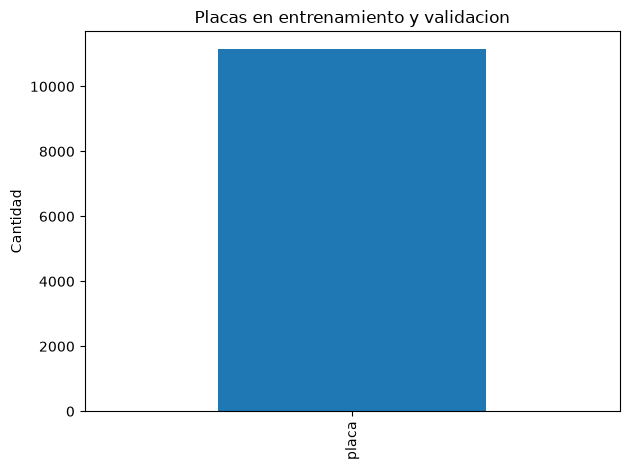

In [16]:
sys.path.insert(0, str(PROJECT_ROOT / 'models'))

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
SPLIT_MANIFEST = FINAL_TEST_ROOT / 'split_manifest.json'
MODEL_DATA_ROOT = PROJECT_ROOT / 'models' / 'training_data'

source_images = sorted(
    path for path in (DATA_ROOT / 'images').iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
)
label_paths = {path.stem: path for path in (DATA_ROOT / 'labels').glob('*.txt')}
paired_images = [path for path in source_images if path.stem in label_paths]
if len(paired_images) != len(source_images):
    print(f'Pares validos: {len(paired_images)}; imagenes sin etiqueta: {len(source_images) - len(paired_images)}')

if REBUILD_DATASET or not SPLIT_MANIFEST.exists():
    shuffled = paired_images.copy()
    random.Random(SEED).shuffle(shuffled)
    final_test_count = max(1, round(len(shuffled) * FINAL_TEST_RATIO))
    final_test_names = {path.name for path in shuffled[:final_test_count]}
    SPLIT_MANIFEST.parent.mkdir(parents=True, exist_ok=True)
    SPLIT_MANIFEST.write_text(json.dumps({
        'seed': SEED,
        'final_test_ratio': FINAL_TEST_RATIO,
        'source_count': len(paired_images),
        'final_test_images': sorted(final_test_names),
    }, indent=2))
else:
    manifest = json.loads(SPLIT_MANIFEST.read_text())
    final_test_names = set(manifest['final_test_images'])
    if not final_test_names.issubset({path.name for path in paired_images}):
        raise RuntimeError('La fuente de datos cambio despues de crear la reserva. Usa REBUILD_DATASET = True.')

training_images = [path for path in paired_images if path.name not in final_test_names]
if REBUILD_DATASET or not MODEL_DATA_ROOT.exists():
    if MODEL_DATA_ROOT.exists():
        shutil.rmtree(MODEL_DATA_ROOT)
    (MODEL_DATA_ROOT / 'images').mkdir(parents=True, exist_ok=True)
    (MODEL_DATA_ROOT / 'labels').mkdir(parents=True, exist_ok=True)
    for image_path in training_images:
        shutil.copy2(image_path, MODEL_DATA_ROOT / 'images' / image_path.name)
        shutil.copy2(label_paths[image_path.stem], MODEL_DATA_ROOT / 'labels' / f'{image_path.stem}.txt')

(FINAL_TEST_ROOT / 'images').mkdir(parents=True, exist_ok=True)
(FINAL_TEST_ROOT / 'labels').mkdir(parents=True, exist_ok=True)
for image_path in paired_images:
    if image_path.name in final_test_names:
        shutil.copy2(image_path, FINAL_TEST_ROOT / 'images' / image_path.name)
        normalized, _ = read_yolo_label(label_paths[image_path.stem])
        (FINAL_TEST_ROOT / 'labels' / f'{image_path.stem}.txt').write_text(
            "\n".join(normalized) + ("\n" if normalized else "")
        )

DATASET_ROOT, CLASS_NAMES = build_dataset(
    MODEL_DATA_ROOT, DATASET_ROOT, val_ratio=INNER_VAL_RATIO, seed=SEED, force=REBUILD_DATASET
)
print('Clases:', CLASS_NAMES)
print('Dataset YAML:', DATASET_ROOT / 'dataset.yaml')
print(f'Total de imagenes con etiqueta: {len(paired_images)}')
print(f'Entrenamiento + validacion interna: {len(training_images)} ({len(training_images) / len(paired_images):.1%})')
print(f'Evaluacion final aislada: {len(final_test_names)} ({len(final_test_names) / len(paired_images):.1%})')

size_counts = Counter()
for image_path in source_images:
    with Image.open(image_path) as image:
        size_counts[image.size] += 1
print(f'Dimensiones distintas: {len(size_counts)}')
print('Dimensiones mas frecuentes:', size_counts.most_common(10))
if len(size_counts) == 1:
    print('Todas las imagenes tienen el mismo tamano.')
else:
    print('Las imagenes no tienen todas el mismo tamano; YOLO las redimensionara a IMAGE_SIZE durante el entrenamiento.')

train_images = list((DATASET_ROOT / 'images' / 'train').glob('*'))
val_images = list((DATASET_ROOT / 'images' / 'val').glob('*'))
print(f'Division interna: train={len(train_images)} ({len(train_images) / (len(train_images) + len(val_images)):.1%}), val={len(val_images)} ({len(val_images) / (len(train_images) + len(val_images)):.1%})')

label_files = list((DATASET_ROOT / 'labels').rglob('*.txt'))
class_counts = {}
for label_file in label_files:
    for line in label_file.read_text().splitlines():
        if line.strip():
            class_id = int(line.split()[0])
            class_counts[class_id] = class_counts.get(class_id, 0) + 1
counts = pd.Series(class_counts).sort_index()
counts.index = [CLASS_NAMES[int(index)] for index in counts.index]
counts.plot(kind='bar', title='Placas en entrenamiento y validacion', ylabel='Cantidad')
plt.tight_layout()
plt.show()

## 3. Busqueda aleatoria y entrenamiento reanudable

Se prueban configuraciones con `AdamW`, augmentations, `patience=PATIENCE` y early stopping. Si la metrica no mejora durante `PATIENCE` epocas, Ultralytics detiene esa prueba y conserva `best.pt`.

Cada prueba guarda checkpoints periodicamente en Google Drive. Si Colab se desconecta, vuelve a ejecutar esta celda: cuando encuentre `last.pt`, continua desde los pesos y la epoca guardados. Los resultados terminados se registran en `search_results.json` y no se repiten.

La primera prueba parte de `yolov8n.pt`. Las pruebas siguientes se inicializan con uno de los tres mejores modelos disponibles hasta ese momento, por lo que sus pesos y bias aprendidos si se usan como punto de partida. `TRIALS`, `EPOCHS`, `BATCH_SIZE` y `PATIENCE` son parametros ajustables segun el tiempo de GPU disponible.

In [6]:
SEARCH_SPACE = {
    'lr0': [0.0005, 0.001, 0.005],
    'lrf': [0.01, 0.05, 0.1],
    'weight_decay': [0.0001, 0.0005, 0.001],
    'hsv_h': [0.01, 0.02], 'hsv_s': [0.5, 0.7],
    'hsv_v': [0.3, 0.5], 'degrees': [0.0, 5.0],
    'scale': [0.3, 0.5], 'fliplr': [0.0, 0.5],
    'mosaic': [0.5, 1.0], 'mixup': [0.0, 0.1],
    'dropout': [0.0, 0.1],
}
RESULTS_FILE = OUTPUT_ROOT / 'search_results_final_holdout.json'
if RESULTS_FILE.exists():
    results = json.loads(RESULTS_FILE.read_text())
else:
    results = []
completed_trials = {item['trial'] for item in results}

for trial in range(1, TRIALS + 1):
    if trial in completed_trials:
        print(f'Trial {trial}/{TRIALS} ya registrado; se omite.')
        continue

    run_name = f'random_trial_{trial:03d}'
    run_dir = RUNS_ROOT / run_name
    last_checkpoint = run_dir / 'weights' / 'last.pt'
    best_checkpoint = run_dir / 'weights' / 'best.pt'
    previous_best = sorted(results, key=lambda item: item['score'], reverse=True)[:3]
    initial_weights = WEIGHTS if not previous_best else previous_best[(trial - 1) % len(previous_best)]['weights']
    config = {name: random.Random(SEED + trial).choice(values) for name, values in SEARCH_SPACE.items()}

    if last_checkpoint.exists():
        print(f'Reanudando {run_name} desde {last_checkpoint}')
        model = YOLO(str(last_checkpoint))
        model.train(resume=True)
        initialization = str(last_checkpoint)
    else:
        print(f'Iniciando {run_name} desde {initial_weights}')
        model = YOLO(initial_weights)
        model.train(
            data=str(DATASET_ROOT / 'dataset.yaml'), epochs=EPOCHS, imgsz=IMAGE_SIZE,
            batch=BATCH_SIZE, device=DEVICE, workers=WORKERS, patience=PATIENCE,
            seed=SEED + trial, project=str(RUNS_ROOT), name=run_name, exist_ok=True,
            optimizer='AdamW', amp=True, save_period=5, **config
        )
        initialization = initial_weights

    if not best_checkpoint.exists():
        raise FileNotFoundError(f'No se encontro el mejor checkpoint: {best_checkpoint}')
    metrics = YOLO(str(best_checkpoint)).val(
        data=str(DATASET_ROOT / 'dataset.yaml'), split='val', imgsz=IMAGE_SIZE, device=DEVICE
    )
    score = float(metrics.box.map)
    results.append({
        'trial': trial,
        'score': score,
        'weights': str(best_checkpoint),
        'initialization': initialization,
        'hyperparameters': config,
    })
    results = sorted(results, key=lambda item: item['score'], reverse=True)
    RESULTS_FILE.write_text(json.dumps(results, indent=2))
    print(f'Trial {trial}/{TRIALS}: mAP50-95 validacion={score:.5f}. Progreso guardado en Drive.')

    if trial < TRIALS:
        print('Esperando 10 minutos antes del siguiente entrenamiento...')
        time.sleep(600)

results = sorted(results, key=lambda item: item['score'], reverse=True)
pd.DataFrame([{'trial': item['trial'], 'mAP50-95 validacion': item['score']} for item in results])

Trial 1/15 ya registrado; se omite.
Trial 2/15 ya registrado; se omite.
Trial 3/15 ya registrado; se omite.
Trial 4/15 ya registrado; se omite.
Reanudando random_trial_005 desde /home/lukga/Programacion/CienciaDeDatos/clase/Placas/runs_colab/random_trial_005/weights/last.pt
New https://pypi.org/project/ultralytics/8.4.150 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.148 🚀 Python-3.13.0 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5050 Laptop GPU, 8151MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/lukga/Programacion/CienciaDeDatos/clase/Placas/models/yolo_dataset_final_holdout/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_mo

,trial,mAP50-95 validacion
0,2,0.945578
1,5,0.944115
2,7,0.943897
3,4,0.943720
4,9,0.943694
5,14,0.943411
6,13,0.943061
7,15,0.941937
8,12,0.941656
9,1,0.940796


## 4. Graficas de entrenamiento

Cada ejecucion de Ultralytics genera `results.png`, `confusion_matrix.png`, curvas Precision-Recall y `results.csv`.

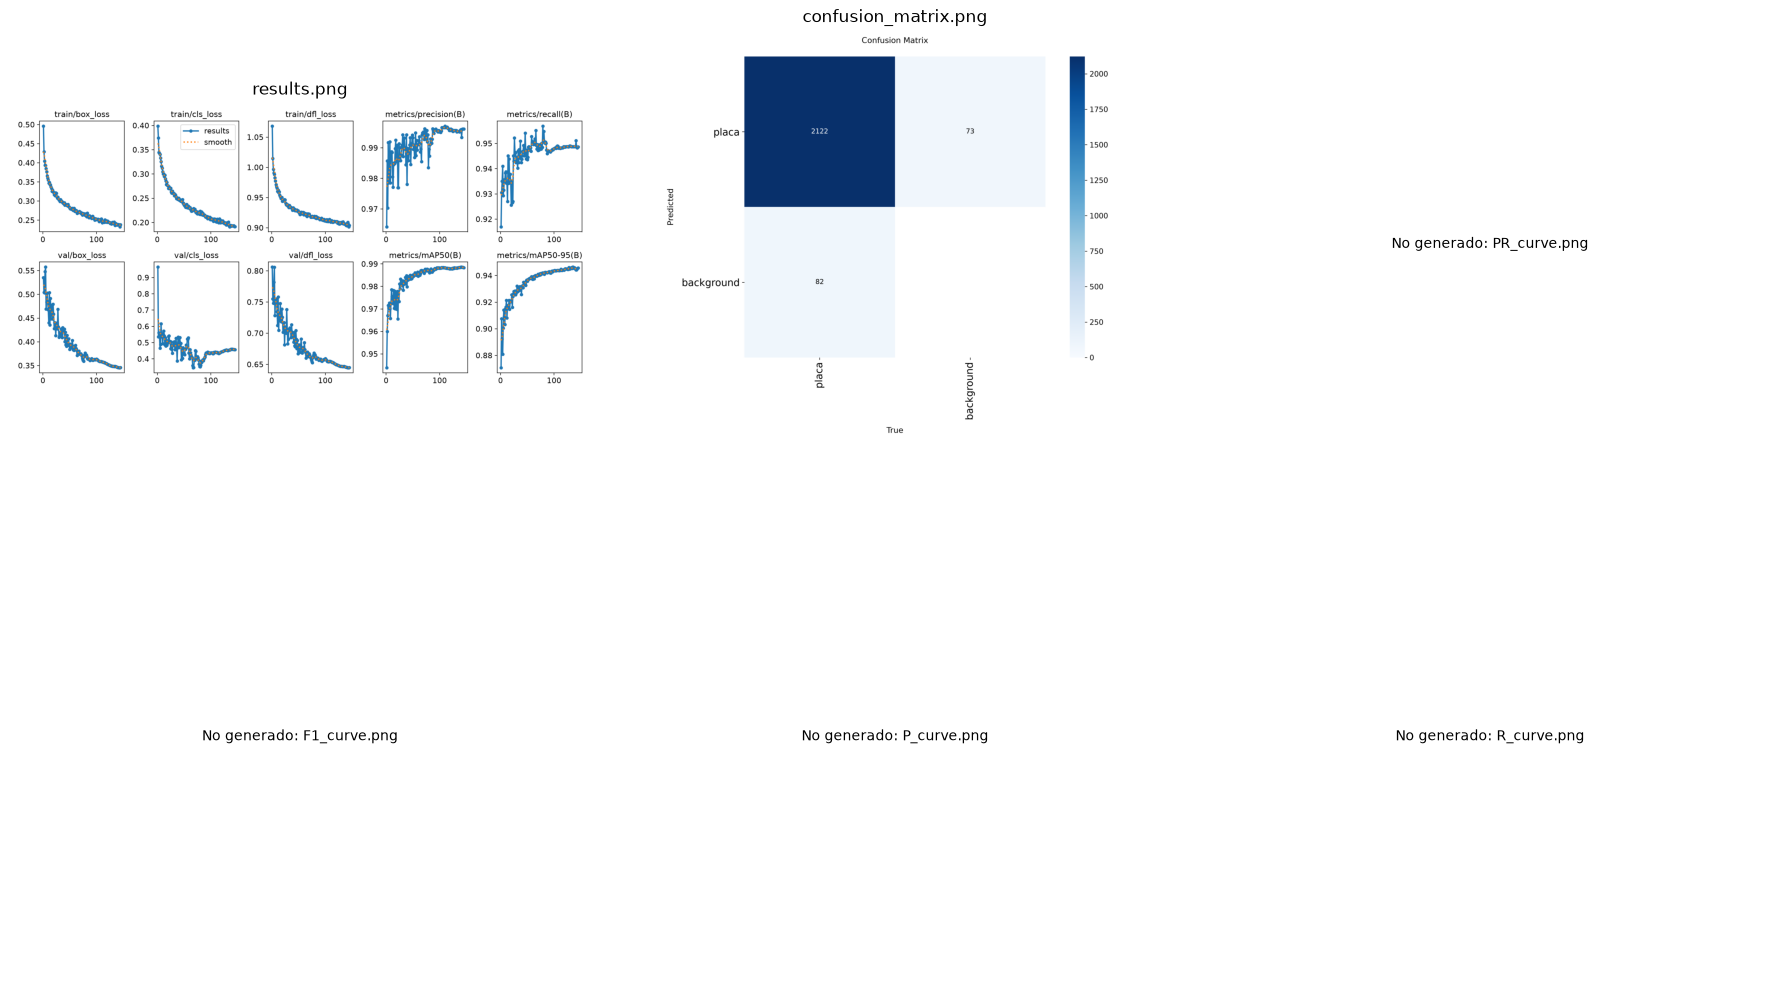

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
140,141,13509.1,0.23855,0.19281,0.90752,0.99337,0.95109,0.98855,0.94423,0.34578,0.45781,0.64499,0.000734,0.000734,0.000734
141,142,13581.7,0.23844,0.19315,0.90904,0.99612,0.94873,0.98854,0.94419,0.34547,0.45908,0.64461,0.000732,0.000732,0.000732
142,143,13652.7,0.23743,0.19346,0.90591,0.99619,0.94825,0.98849,0.94491,0.34530,0.45856,0.64454,0.000730,0.000730,0.000730
143,144,13732.8,0.23271,0.19162,0.90160,0.99619,0.94844,0.98842,0.94557,0.34543,0.45753,0.64461,0.000728,0.000728,0.000728
144,145,13803.7,0.23821,0.19161,0.90401,0.99619,0.94862,0.98836,0.94564,0.34569,0.45668,0.64484,0.000726,0.000726,0.000726


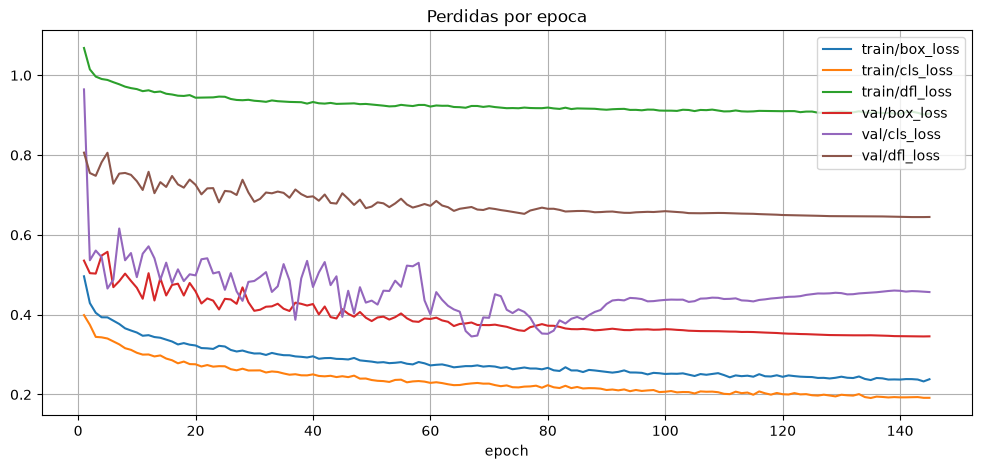

In [7]:
best_trial = results[0]
best_run = RUNS_ROOT / f"random_trial_{best_trial['trial']:03d}"
plot_files = ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'F1_curve.png', 'P_curve.png', 'R_curve.png']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, filename in zip(axes.flat, plot_files):
    path = best_run / filename
    if path.exists():
        axis.imshow(Image.open(path))
        axis.set_title(filename)
    else:
        axis.text(0.5, 0.5, f'No generado: {filename}', ha='center')
    axis.axis('off')
plt.tight_layout()
plt.show()

csv_path = best_run / 'results.csv'
if csv_path.exists():
    history = pd.read_csv(csv_path)
    history.columns = history.columns.str.strip()
    display(history.tail())
    history.plot(x='epoch', y=[column for column in history.columns if 'loss' in column], figsize=(12, 5), title='Perdidas por epoca')
    plt.grid()
    plt.show()

## 5. Guardar los tres mejores modelos

Los modelos se ordenan usando solamente la `mAP50-95` de la validacion interna. Los archivos `.pt` contienen la arquitectura, los pesos y los bias aprendidos. Se copian los tres mejores y sus configuraciones; la evaluacion final sobre el 20% aislado se hace en la siguiente celda, despues de seleccionar el ganador.

In [8]:
for rank, item in enumerate(results[:3], start=1):
    destination = OUTPUT_ROOT / f'model_{rank}'
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(item['weights'], destination / 'best.pt')
    metadata = {
        'rank': rank, 'trial': item['trial'], 'metric': 'mAP50-95',
        'score': item['score'], 'hyperparameters': item['hyperparameters'],
        'weights_file': 'best.pt',
    }
    (destination / 'configuration.txt').write_text(json.dumps(metadata, indent=2))
shutil.copy2(results[0]['weights'], PROJECT_ROOT / 'models' / 'best.pt')
print(f'Modelos guardados en {OUTPUT_ROOT}')
print('El mejor peso para la API:', PROJECT_ROOT / 'models' / 'best.pt')

Modelos guardados en /home/lukga/Programacion/CienciaDeDatos/clase/Placas/top_models
El mejor peso para la API: /home/lukga/Programacion/CienciaDeDatos/clase/Placas/models/best.pt


## 6. Evaluacion final sobre datos nunca usados

Esta evaluacion se ejecuta despues de elegir el mejor modelo con la validacion interna. El conjunto final no participa en el entrenamiento, early stopping, busqueda de hiperparametros ni seleccion del top 3; su resultado es la estimacion final del rendimiento.

In [10]:
best_model = YOLO(results[0]['weights'])
final_test_yaml = FINAL_TEST_ROOT / 'dataset.yaml'
final_test_yaml.write_text('\n'.join([
    f'path: {FINAL_TEST_ROOT.resolve().as_posix()}',
    'train: images',
    'val: images',
    'test: images',
    f'nc: {len(CLASS_NAMES)}',
    'names:',
    *[f'  {index}: {name}' for index, name in enumerate(CLASS_NAMES)],
]) + '\n')

final_metrics = best_model.val(
    data=str(final_test_yaml), split='test', imgsz=IMAGE_SIZE, device=DEVICE
)
print(f"Modelo ganador: trial {results[0]['trial']}")
print(f"mAP50-95 en evaluacion final: {float(final_metrics.box.map):.5f}")
print(f"mAP50 en evaluacion final: {float(final_metrics.box.map50):.5f}")

final_images = list((FINAL_TEST_ROOT / 'images').glob('*'))
sample_images = final_images[: min(6, len(final_images))]
predictions = best_model.predict(
    source=[str(path) for path in sample_images], conf=0.35,
    imgsz=IMAGE_SIZE, device=DEVICE
)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for axis, prediction in zip(axes.flat, predictions):
    axis.imshow(prediction.plot()[..., ::-1])
    axis.axis('off')
plt.tight_layout()
plt.show()

TypeError: object of type 'NoneType' has no len()